In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

In [2]:
HI_dmax_clim = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/HI_dmaxclim.nc')
HI_dmax_clim

<xarray.Dataset> Size: 478kB
Dimensions:            (month: 12, latitude: 82, longitude: 121)
Coordinates:
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude           (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude          (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
Data variables:
    HI_daily_max_clim  (month, latitude, longitude) float32 476kB ...

In [4]:
HI_dmax = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/dailymax_HI.nc')
HI_dmax

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 1GB ...

In [11]:
HIdmax_anom = HI_dmax['HI_daily_max'].groupby('time.month') - HI_dmax_clim
HIdmax_anom = HIdmax_anom['HI_daily_max_clim'].rename('HI_dmax_anom')
HIdmax_anom

<xarray.DataArray 'HI_dmax_anom' (time: 31471, latitude: 82, longitude: 121)> Size: 1GB
array([[[-2.2869186 , -2.5064545 , -2.804306  , ..., -1.4596558 ,
         -1.1788406 , -0.20955658],
        [-2.188652  , -2.4162521 , -2.7421417 , ..., -1.3799286 ,
         -0.13363647, -1.1835327 ],
        [-2.0727615 , -2.3111572 , -2.5543365 , ...,  0.954834  ,
         -1.2136536 , -1.3527527 ],
        ...,
        [ 2.1585312 ,  2.0330505 ,  1.9041443 , ...,  1.6762161 ,
          1.9024124 ,  2.327797  ],
        [ 2.139183  ,  2.0049057 ,  1.9147034 , ...,  0.5435562 ,
          1.1119003 ,  1.6317368 ],
        [ 1.8563843 ,  1.6500168 ,  1.4775162 , ...,  0.5783844 ,
          0.39038086,  0.9462967 ]],

       [[-2.1257172 , -2.1235352 ,  0.6615143 , ..., -0.22929382,
          0.22852325,  1.4149399 ],
        [-2.0496826 , -2.207985  , -2.452568  , ...,  0.27303314,
          1.7871399 ,  2.7879562 ],
        [-1.8559189 , -2.0732956 , -2.2474365 , ...,  2.6182098 ,
          2.682457  ,  1.6036453 ],
...
          4.3591766 ,  4.519905  ],
        [ 4.8866425 ,  5.2508163 ,  5.3712616 , ...,  4.169304  ,
          4.3558044 ,  4.4233627 ],
        [ 5.025032  ,  5.354477  ,  5.338089  , ...,  4.0356445 ,
          4.160881  ,  4.1572723 ]],

       [[-4.2801895 , -4.028702  , -0.9921417 , ...,  1.319046  ,
          1.048172  ,  0.86815643],
        [-4.2926407 , -3.994133  , -3.6334686 , ...,  2.0337982 ,
          1.5667038 ,  1.870369  ],
        [-4.445717  , -4.0115433 , -3.463234  , ...,  3.078537  ,
          2.1004257 ,  1.543251  ],
        ...,
        [ 2.3886719 ,  2.6019135 ,  2.7244186 , ...,  4.6937866 ,
          4.74131   ,  4.731148  ],
        [ 2.401802  ,  2.5360336 ,  2.6148376 , ...,  4.5005646 ,
          4.690483  ,  4.696556  ],
        [ 2.644722  ,  2.8029099 ,  2.8684921 , ...,  4.4440384 ,
          4.626404  ,  4.625992  ]]],
      shape=(31471, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 252kB 1940-01-01 1940-01-02 ... 2026-02-28
    month      (time) int64 252kB 1 1 1 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2 2 2
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

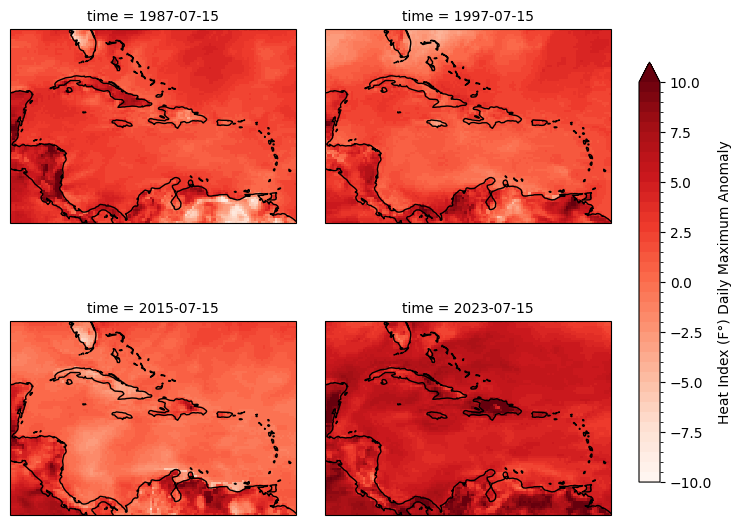

In [30]:
# strong ENSO in JJA
HIdmaxanom_plot = HIdmax_anom.sel(time=['1987-07-15', '1997-07-15', '2015-07-15', '2023-07-15']).plot(col='time',
                                                         col_wrap=2,
                                                         transform=ccrs.PlateCarree(),
                                                         cmap='Reds',
                                                         levels=np.arange(-10, 10.5, 0.5),
                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                         add_colorbar=False
                                                              )
cax = HIdmaxanom_plot.fig.add_axes([0.92, 0.15, 0.03, 0.70])
HIdmaxanom_plot.fig.colorbar(HIdmaxanom_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Anomaly')
HIdmaxanom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

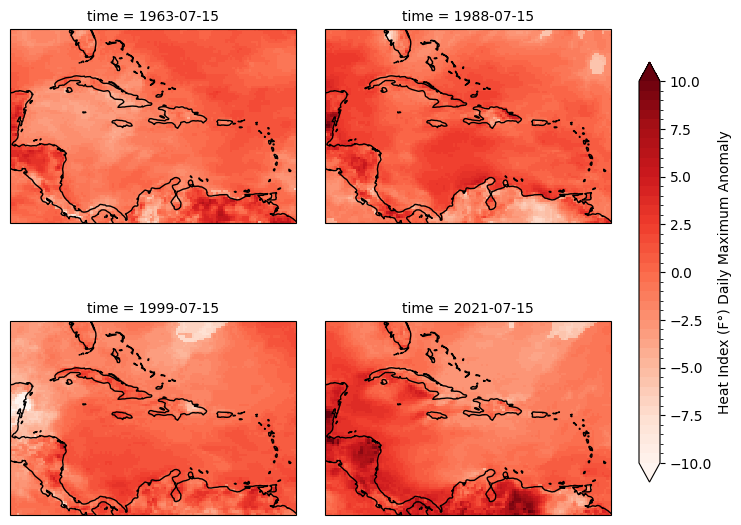

In [29]:
HIdmaxanom_plot = HIdmax_anom.sel(time=['1963-07-15', '1988-07-15', '1999-07-15', '2021-07-15']).plot(col='time',
                                                         col_wrap=2,
                                                         transform=ccrs.PlateCarree(),
                                                         cmap='Reds',
                                                         levels=np.arange(-10, 10.5, 0.5),
                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                         add_colorbar=False
                                                              )
cax = HIdmaxanom_plot.fig.add_axes([0.92, 0.15, 0.03, 0.70])
HIdmaxanom_plot.fig.colorbar(HIdmaxanom_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Anomaly')
HIdmaxanom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

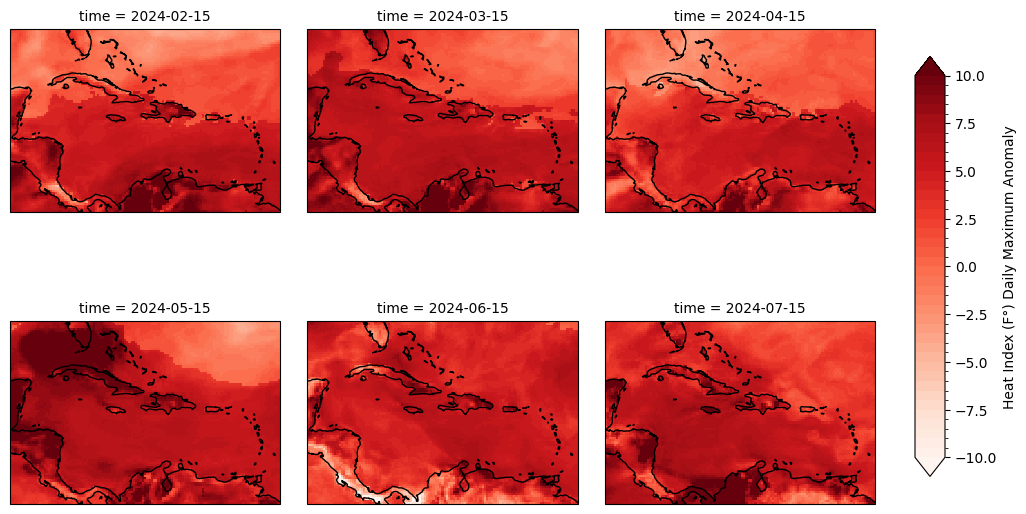

In [28]:
HIdmaxanom_plot = HIdmax_anom.sel(time=['2024-02-15', '2024-03-15', '2024-04-15', '2024-05-15', '2024-06-15', '2024-07-15']).plot(col='time',
                                                         col_wrap=3,
                                                         transform=ccrs.PlateCarree(),
                                                         cmap='Reds',
                                                         levels=np.arange(-10, 10.5, 0.5),
                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                         add_colorbar=False
                                                              )
cax = HIdmaxanom_plot.fig.add_axes([0.92, 0.15, 0.03, 0.70])
HIdmaxanom_plot.fig.colorbar(HIdmaxanom_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Anomaly')
HIdmaxanom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)